In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


## Ocean mask 

In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

In [4]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20), time= slice('1979', None))

w500 = w500.where(ocean_mask)

fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(20, -20), time = slice('1979', None))
sst = sst.where(ocean_mask)



In [5]:
#convert to hpa/day
#w500 = w500*(24*3600/100)

#creat weights
weights = np.cos(np.deg2rad(w500.lat))
w = w500.sel(time = slice('1991', '2020')).where(w500.time.dt.month.isin([4,5,6,7,8,9])).mean(['time'])


In [6]:
dsst = (sst.sel(time = slice('2023-04', '2023-09')).mean(['time'])-sst.sel(time = slice('2022-04', '2022-09'))
        .mean(['time']))
#w = w500.sel(time = slice('2023-{}'.format(4), '2023-{}'.format(9))).mean(['time'])


# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values23 = dsst['sst'].values
w_values23 = w['w'].values


# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values23) & ~np.isnan(w_values23)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values23 = dsst_values23[valid_mask]
w_values23 = w_values23[valid_mask]*(24*3600/100)



In [7]:
dsst = (sst.sel(time = slice('2015-04', '2015-09')).mean(['time'])-sst.sel(time = slice('2014-04', '2014-09'))
        .mean(['time']))
#w = w500.sel(time = slice('2015-{}'.format(4), '2015-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values15 = dsst['sst'].values
w_values15 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values15) & ~np.isnan(w_values15)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values15 = dsst_values15[valid_mask]
w_values15 = w_values15[valid_mask]*(24*3600/100)



In [8]:
dsst = (sst.sel(time = slice('2009-04', '2009-09')).mean(['time'])-sst.sel(time = slice('2008-04', '2008-09'))
        .mean(['time']))
#w = w500.sel(time = slice('2009-{}'.format(4), '2009-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values09 = dsst['sst'].values
w_values09 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values09) & ~np.isnan(w_values09)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values09 = dsst_values09[valid_mask]
w_values09 = w_values09[valid_mask]*(24*3600/100)



In [9]:
dsst = (sst.sel(time = slice('1982-04', '1982-09')).mean(['time'])-sst.sel(time = slice('1981-04', '1981-09')).mean(['time']))
#w = w500.sel(time = slice('1982-{}'.format(4), '1982-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values82 = dsst['sst'].values
w_values82 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values82) & ~np.isnan(w_values82)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values82 = dsst_values82[valid_mask]
w_values82 = w_values82[valid_mask]*(24*3600/100)



In [10]:
dsst = (sst.sel(time = slice('1987-04', '1987-09')).mean(['time'])-sst.sel(time = slice('1986-04', '1986-09')).mean(['time']))
#w = w500.sel(time = slice('1987-{}'.format(4), '1987-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values87 = dsst['sst'].values
w_values87 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values87) & ~np.isnan(w_values87)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values87 = dsst_values87[valid_mask]
w_values87 = w_values87[valid_mask]*(24*3600/100)



In [11]:
dsst = (sst.sel(time = slice('1991-04', '1991-09')).mean(['time'])-sst.sel(time = slice('1990-04', '1990-09')).mean(['time']))
#w = w500.sel(time = slice('1991-{}'.format(4), '1991-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values91 = dsst['sst'].values
w_values91 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values91) & ~np.isnan(w_values91)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values91 = dsst_values91[valid_mask]
w_values91 = w_values91[valid_mask]*(24*3600/100)



In [12]:
dsst = (sst.sel(time = slice('1997-04', '1997-09')).mean(['time'])-sst.sel(time = slice('1996-04', '1996-09')).mean(['time']))
#w = w500.sel(time = slice('1997-{}'.format(4), '1997-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dsst and w are Datasets with single DataArrays 'sst' and 'w')
dsst_values97 = dsst['sst'].values
w_values97 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dsst_values97) & ~np.isnan(w_values97)

# Apply the mask to flatten the data arrays, only keeping valid entries
dsst_values97 = dsst_values97[valid_mask]
w_values97 = w_values97[valid_mask]*(24*3600/100)



In [13]:
import pandas as pd

# Set the rc parameters for LaTeX
#plt.rc('text', usetex=True)
#plt.rc('font', family='serif')

# Variable to control the fontsize of the axis labels
fontsize = 20

In [14]:
# Flatten and clean w values
w_flat = w['w'].values.flatten()*(24*3600/100)
w_flat = w_flat[~np.isnan(w_flat)]

# Define bin centers at 5%, 15%, ..., 95% (total 10 bins)
quantile_centers = np.linspace(0.05, 0.95, 10)
bin_centers = np.quantile(w_flat, quantile_centers)

# Now compute edges by splitting halfway between centers
# First, pad with "fake" outer edges to get 11 actual bin edges
edges = np.zeros(len(bin_centers) + 1)
edges[1:-1] = (bin_centers[:-1] + bin_centers[1:]) / 2
edges[0] = w_flat.min() - 1e-6  # just below min to include all data
edges[-1] = w_flat.max() + 1e-6  # just above max to include all data

w_bins = edges  # use this in np.digitize


# Define fewer bins for w
w_bins = np.linspace(-80, 40, num=14) 
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

In [15]:
# Prepare data for 2023
data_2023 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values23, bins=w_bins), w_values23) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values23, bins=w_bins), dsst_values23) if 0 < i <= len(bin_centers)]
})

In [16]:
# Prepare data for 2015
data_2015 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values15, bins=w_bins), w_values15) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values15, bins=w_bins), dsst_values15) if 0 < i <= len(bin_centers)]
})

In [17]:
# Prepare data for 2009
data_2009 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values09, bins=w_bins), w_values09) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values09, bins=w_bins), dsst_values09) if 0 < i <= len(bin_centers)]

})

In [18]:
# Prepare data for 2082
data_1982 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values82, bins=w_bins), w_values82) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values82, bins=w_bins), dsst_values82) if 0 < i <= len(bin_centers)]
})

In [19]:
# Prepare data for 2091
data_1991 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values91, bins=w_bins), w_values91) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values91, bins=w_bins), dsst_values91) if 0 < i <= len(bin_centers)]
})

In [20]:
# Prepare data for 2097
data_1997 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values97, bins=w_bins), w_values97) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values97, bins=w_bins), dsst_values97) if 0 < i <= len(bin_centers)]
})

In [21]:
# Prepare data for 2087
data_1987 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values87, bins=w_bins), w_values87) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values87, bins=w_bins), dsst_values87) if 0 < i <= len(bin_centers)]
})

In [22]:
w_compound = np.concatenate([w_values82, w_values87, w_values91, w_values97, w_values09, w_values15])

In [23]:
dsst_compound = np.concatenate([dsst_values82, dsst_values87, dsst_values91, dsst_values97, dsst_values09, dsst_values15])

In [24]:

# Prepare data for 2023
data_2023 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values23, bins=w_bins), w_values23) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_values23, bins=w_bins), dsst_values23) if 0 < i <= len(bin_centers)]
})

In [25]:
data_compound = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_compound, bins=w_bins), w_compound) if 0 < i <= len(bin_centers)],
    'Delta SST': [dsst for i, dsst in zip(np.digitize(w_compound, bins=w_bins), dsst_compound) if 0 < i <= len(bin_centers)]
})

In [26]:
# Calculate mean and std for each bin
means_2023 = []
stds_2023 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_2023['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_2023['Delta SST'][mask]
    # Calculate mean and std
    means_2023.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_2023.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [27]:
# Calculate mean and std for each bin
means_1997 = []
stds_1997 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1997['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1997['Delta SST'][mask]
    # Calculate mean and std
    means_1997.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1997.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [28]:
# Calculate mean and std for each bin
means_1982 = []
stds_1982 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1982['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1982['Delta SST'][mask]
    # Calculate mean and std
    means_1982.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1982.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [29]:
# Calculate mean and std for each bin
means_1991 = []
stds_1991 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1991['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1991['Delta SST'][mask]
    # Calculate mean and std
    means_1991.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1991.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [30]:
# Calculate mean and std for each bin
means_1987 = []
stds_1987 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1987['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1987['Delta SST'][mask]
    # Calculate mean and std
    means_1987.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1987.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [31]:
# Calculate mean and std for each bin
means_2015 = []
stds_2015 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_2015['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_2015['Delta SST'][mask]
    # Calculate mean and std
    means_2015.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_2015.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [32]:
# Calculate mean and std for each bin
means_2015 = []
stds_2015 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_2015['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_2015['Delta SST'][mask]
    # Calculate mean and std
    means_2015.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_2015.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [33]:
means = [means_1982, means_1987, means_1991, means_1997, means_2015]
stds = [stds_1982, stds_1987, stds_1991, stds_1997, stds_2015]

compounds = [[m, s] for m,s in zip(means, stds)]

In [34]:
# Calculate mean and std for each bin
means_compound = []
stds_compound = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_compound['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_compound['Delta SST'][mask]
    # Calculate mean and std
    means_compound.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_compound.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


Text(0, 0.5, 'ΔSST [K]')

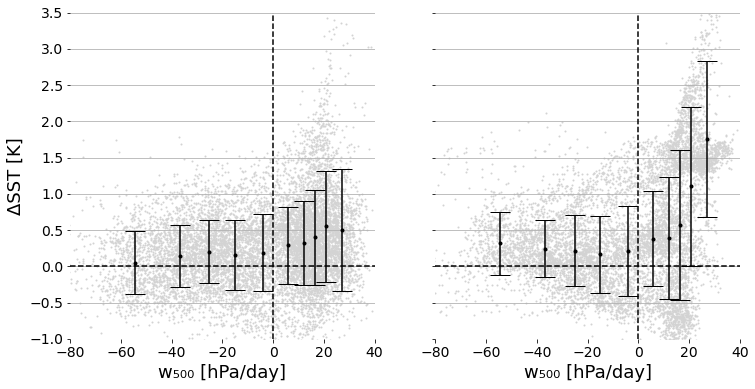

In [35]:
fig, axes = plt.subplots(1, 2, figsize = (12,6), sharey = True)

#axes[0].set_title('2023')
#axes[1].set_title('Compound')


axes[1].errorbar(x = bin_centers, y = means_2023, yerr = stds_2023,
                 fmt = '.', c = 'k', capsize = 10)
axes[1].scatter(w_values23, dsst_values23, s = 1, c = 'lightgrey')

axes[0].scatter(w_compound[::5], dsst_compound[::5], s = 1, c = 'lightgrey')
axes[0].errorbar(x = bin_centers, y = means_compound, yerr = stds_compound,
                 fmt = '.', c = 'k', capsize = 10)





for ax in axes:
    ax.set_ylim(-1,3.5)
    ax.set_xlim(-80, 40)
    ax.axhline(0, c = 'k', linestyle = '--')
    ax.axvline(0, c = 'k', linestyle = '--')   
    ax.spines[:].set_visible(False)
    

    ax.set_xlabel('w₅₀₀ [hPa/day]', fontsize = 18, fontweight = 'normal')
    ax.tick_params(axis='both', labelsize=14) 
    ax.grid(axis = 'y')

axes[0].set_ylabel('ΔSST [K]', fontsize = 18, fontweight = 'normal')

    

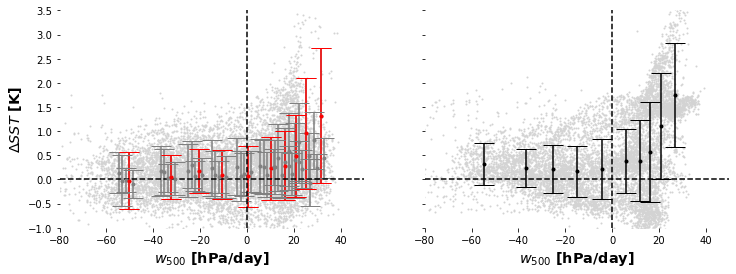

In [37]:
fig, axes = plt.subplots(1, 2, figsize = (12,4), sharey = True)

axes[0].scatter(w_compound[::5], dsst_compound[::5], s = 1, c = 'lightgrey')

axes[1].scatter(w_values23, dsst_values23, s = 1, c = 'lightgrey')


box_color = 'skyblue'


i = 0
for tup in compounds:
    axes[0].errorbar(x = bin_centers+i, y = tup[0], yerr = tup[1],
                 fmt = '.', capsize = 10, c = 'grey')

    if i == 4.5:
        axes[0].errorbar(x = bin_centers+i, y = tup[0], yerr = tup[1],
                 fmt = '.', capsize = 10, c = 'r')

    i+=1.5




axes[1].errorbar(x = bin_centers, y = means_2023, yerr = stds_2023,
                 fmt = '.', c = 'k', capsize = 10)


for ax in axes:
    ax.set_ylim(-1,3.5)
    ax.set_xlim(-80, 50)
    ax.axhline(0, c = 'k', linestyle = '--')
    ax.axvline(0, c = 'k', linestyle = '--')   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_xlabel(r'$w_{500}$ [hPa/day]')
axes[0].set_ylabel(r'$\Delta SST$ [K]');

ValueError: x and y must be the same size

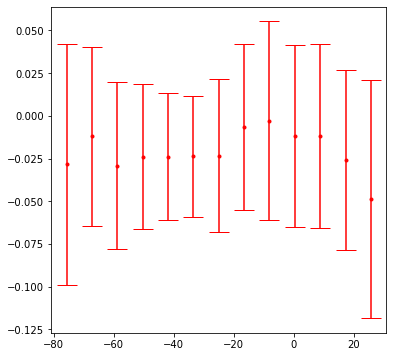

In [83]:
fig, ax = plt.subplots(1, 1, figsize = (6,6))

#ax.set_title('2023')
#ax.set_title('Compound')


ax.errorbar(x = bin_centers, y = means_2023, yerr = stds_2023,
                 fmt = '.', c = 'r', capsize = 10, zorder = 20)
ax.scatter(w_values23, dsst_values23, s = 1, c = 'red', zorder = 10)

ax.scatter(w_compound[::5], dsst_compound[::5], s = 1, c = 'lightgrey')
ax.errorbar(x = bin_centers, y = means_compound, yerr = stds_compound,
                 fmt = '.', c = 'k', capsize = 10)





for ax in [ax]:
    ax.set_ylim(-1,3.5)
    ax.set_xlim(-80, 50)
    ax.axhline(0, c = 'k', linestyle = '--')
    ax.axvline(0, c = 'k', linestyle = '--')   
    ax.spines[:].set_visible(False)
    ax.set_ylabel(r'$\Delta SST$ [K]', fontsize = 16)

ax.set_xlabel(r'$w_{500}$ [hPa/day]', fontsize = 16)


In [40]:
import numpy as np
import xarray as xr
import pandas as pd

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [41]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

def encode_time(ds, reference_time = '1958-01-01', period = 'months'):
    ds.time.encoding['calendar'] = '360_day'
    ds.time.encoding['units'] = '{} since {}'.format(period, reference_time)
    return ds


## Ocean mask 

In [42]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-20,20))
ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifi
#ocean_mask = masks.seamask # all tropical oceans

In [43]:

fp  = '/data/jmex/ERA5/monthly/clouds/era5_clouds.nc'

clouds = xr.open_dataset(fp).sel(latitude = slice(20, -20), valid_time = slice('1979', '2024-10'))

clouds = clouds.drop(['expver', 'number'])
clouds = clouds.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})
clouds['lon'] = (clouds['lon']+360)%360
clouds = clouds.sortby('lon')

lcc = clouds.where(ocean_mask)#.drop_vars(['lcc', 'mcc', 'lcc'])

In [44]:
fp = '/data/jmex/ERA5/monthly/era5_w500_0-360E_-35-35N.nc'
w500 = decode_time(fp).sel(lat = slice(20, -20), time= slice('1979', None))

w500 = w500.where(ocean_mask)




In [45]:
#convert to hpa/day
#w500 = w500*(24*3600/100)

#creat weights
weights = np.cos(np.deg2rad(w500.lat))


In [46]:
w = w500.sel(time = slice('1990', '2020')).where(w500.time.dt.month.isin([4,5,6,7,8,9])).mean(['time'])


In [47]:
dlcc = (lcc.sel(time = slice('2023-04', '2023-09')).mean(['time'])-lcc.sel(time = slice('2022-04', '2022-09'))
        .mean(['time']))
#w = w500.sel(time = slice('2023-{}'.format(4), '2023-{}'.format(9))).mean(['time'])


# Convert to DataArray if necessary (assuming dlcc and w are Datasets with single DataArrays 'lcc' and 'w')
dlcc_values23 = dlcc['lcc'].values
w_values23 = w['w'].values


# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dlcc_values23) & ~np.isnan(w_values23)

# Apply the mask to flatten the data arrays, only keeping valid entries
dlcc_values23 = dlcc_values23[valid_mask]
w_values23 = w_values23[valid_mask]*(24*3600/100)



In [48]:
dlcc = (lcc.sel(time = slice('2015-04', '2015-09')).mean(['time'])-lcc.sel(time = slice('2014-04', '2014-09'))
        .mean(['time']))
#w = w500.sel(time = slice('2015-{}'.format(4), '2015-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dlcc and w are Datasets with single DataArrays 'lcc' and 'w')
dlcc_values15 = dlcc['lcc'].values
w_values15 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dlcc_values15) & ~np.isnan(w_values15)

# Apply the mask to flatten the data arrays, only keeping valid entries
dlcc_values15 = dlcc_values15[valid_mask]
w_values15 = w_values15[valid_mask]*(24*3600/100)



In [49]:
dlcc = (lcc.sel(time = slice('2009-04', '2009-09')).mean(['time'])-lcc.sel(time = slice('2008-04', '2008-09'))
        .mean(['time']))
w = w500.sel(time = slice('2009-{}'.format(4), '2009-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dlcc and w are Datasets with single DataArrays 'lcc' and 'w')
dlcc_values09 = dlcc['lcc'].values
w_values09 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dlcc_values09) & ~np.isnan(w_values09)

# Apply the mask to flatten the data arrays, only keeping valid entries
dlcc_values09 = dlcc_values09[valid_mask]
w_values09 = w_values09[valid_mask]*(24*3600/100)



In [50]:
dlcc = (lcc.sel(time = slice('1982-04', '1982-09')).mean(['time'])-lcc.sel(time = slice('1981-04', '1981-09')).mean(['time']))
#w = w500.sel(time = slice('1982-{}'.format(4), '1982-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dlcc and w are Datasets with single DataArrays 'lcc' and 'w')
dlcc_values82 = dlcc['lcc'].values
w_values82 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dlcc_values82) & ~np.isnan(w_values82)

# Apply the mask to flatten the data arrays, only keeping valid entries
dlcc_values82 = dlcc_values82[valid_mask]
w_values82 = w_values82[valid_mask]*(24*3600/100)



In [51]:
dlcc = (lcc.sel(time = slice('1987-04', '1987-09')).mean(['time'])-lcc.sel(time = slice('1986-04', '1986-09')).mean(['time']))
#w = w500.sel(time = slice('1987-{}'.format(4), '1987-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dlcc and w are Datasets with single DataArrays 'lcc' and 'w')
dlcc_values87 = dlcc['lcc'].values
w_values87 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dlcc_values87) & ~np.isnan(w_values87)

# Apply the mask to flatten the data arrays, only keeping valid entries
dlcc_values87 = dlcc_values87[valid_mask]
w_values87 = w_values87[valid_mask]*(24*3600/100)



In [52]:
dlcc = (lcc.sel(time = slice('1991-04', '1991-09')).mean(['time'])-lcc.sel(time = slice('1990-04', '1990-09')).mean(['time']))
#w = w500.sel(time = slice('1991-{}'.format(4), '1991-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dlcc and w are Datasets with single DataArrays 'lcc' and 'w')
dlcc_values91 = dlcc['lcc'].values
w_values91 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dlcc_values91) & ~np.isnan(w_values91)

# Apply the mask to flatten the data arrays, only keeping valid entries
dlcc_values91 = dlcc_values91[valid_mask]
w_values91 = w_values91[valid_mask]*(24*3600/100)



In [53]:
dlcc = (lcc.sel(time = slice('1997-04', '1997-09')).mean(['time'])-lcc.sel(time = slice('1996-04', '1996-09')).mean(['time']))
#w = w500.sel(time = slice('1997-{}'.format(4), '1997-{}'.format(9))).mean(['time'])

# Convert to DataArray if necessary (assuming dlcc and w are Datasets with single DataArrays 'lcc' and 'w')
dlcc_values97 = dlcc['lcc'].values
w_values97 = w['w'].values

# Create a mask for valid (non-NaN) entries
valid_mask = ~np.isnan(dlcc_values97) & ~np.isnan(w_values97)

# Apply the mask to flatten the data arrays, only keeping valid entries
dlcc_values97 = dlcc_values97[valid_mask]
w_values97 = w_values97[valid_mask]*(24*3600/100)



In [54]:
import pandas as pd

# Set the rc parameters for LaTeX
#plt.rc('text', usetex=True)
#plt.rc('font', family='serif')

# Variable to control the fontsize of the axis labels
fontsize = 20

# Define fewer bins for w
w_bins = np.linspace(-80, 40, num=14) 
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

In [55]:
# Flatten and clean w values
w_flat = w['w'].values.flatten()*(24*3600/100)
w_flat = w_flat[~np.isnan(w_flat)]

# Define bin centers at 5%, 15%, ..., 95% (total 10 bins)
quantile_centers = np.linspace(0.05, 0.95, 10)
bin_centers = np.quantile(w_flat, quantile_centers)

# Now compute edges by splitting halfway between centers
# First, pad with "fake" outer edges to get 11 actual bin edges
edges = np.zeros(len(bin_centers) + 1)
edges[1:-1] = (bin_centers[:-1] + bin_centers[1:]) / 2
edges[0] = w_flat.min() - 1e-6  # just below min to include all data
edges[-1] = w_flat.max() + 1e-6  # just above max to include all data

w_bins = edges  # use this in np.digitize


In [56]:
# Prepare data for 2023
data_2023 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values23, bins=w_bins), w_values23) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values23, bins=w_bins), dlcc_values23) if 0 < i <= len(bin_centers)]
})

In [57]:
# Prepare data for 2015
data_2015 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values15, bins=w_bins), w_values15) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values15, bins=w_bins), dlcc_values15) if 0 < i <= len(bin_centers)]
})

In [58]:
# Prepare data for 2009
data_2009 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values09, bins=w_bins), w_values09) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values09, bins=w_bins), dlcc_values09) if 0 < i <= len(bin_centers)]

})

In [59]:
# Prepare data for 2082
data_1982 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values82, bins=w_bins), w_values82) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values82, bins=w_bins), dlcc_values82) if 0 < i <= len(bin_centers)]
})

In [60]:
# Prepare data for 2091
data_1991 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values91, bins=w_bins), w_values91) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values91, bins=w_bins), dlcc_values91) if 0 < i <= len(bin_centers)]
})

In [61]:
# Prepare data for 2097
data_1997 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values97, bins=w_bins), w_values97) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values97, bins=w_bins), dlcc_values97) if 0 < i <= len(bin_centers)]
})

In [62]:
# Prepare data for 2087
data_1987 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values87, bins=w_bins), w_values87) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values87, bins=w_bins), dlcc_values87) if 0 < i <= len(bin_centers)]
})

In [63]:
w_compound = np.concatenate([w_values82, w_values87, w_values91, w_values97, w_values09, w_values15])

In [64]:
dlcc_compound = np.concatenate([dlcc_values82, dlcc_values87, dlcc_values91, dlcc_values97, dlcc_values09, dlcc_values15])

In [65]:
# Define fewer bins for w
w_bins = np.linspace(-80, 30, num=14) 
bin_centers = (w_bins[:-1] + w_bins[1:]) / 2

# Prepare data for 2023
data_2023 = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_values23, bins=w_bins), w_values23) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_values23, bins=w_bins), dlcc_values23) if 0 < i <= len(bin_centers)]
})

In [66]:
# Prepare data for 2023
data_compound = pd.DataFrame({
    'Bin Center': [bin_centers[i - 1] for i, w in zip(np.digitize(w_compound, bins=w_bins), w_compound) if 0 < i <= len(bin_centers)],
    'Delta lcc': [dlcc for i, dlcc in zip(np.digitize(w_compound, bins=w_bins), dlcc_compound) if 0 < i <= len(bin_centers)]
})

In [67]:
# Calculate mean and std for each bin
means_2023 = []
stds_2023 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_2023['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_2023['Delta lcc'][mask]
    # Calculate mean and std
    means_2023.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_2023.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [68]:
# Calculate mean and std for each bin
means_1997 = []
stds_1997 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1997['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1997['Delta lcc'][mask]
    # Calculate mean and std
    means_1997.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1997.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [69]:
# Calculate mean and std for each bin
means_1982 = []
stds_1982 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1982['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1982['Delta lcc'][mask]
    # Calculate mean and std
    means_1982.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1982.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [70]:
# Calculate mean and std for each bin
means_1991 = []
stds_1991 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1991['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1991['Delta lcc'][mask]
    # Calculate mean and std
    means_1991.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1991.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [71]:
# Calculate mean and std for each bin
means_1987 = []
stds_1987 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_1987['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_1987['Delta lcc'][mask]
    # Calculate mean and std
    means_1987.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_1987.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [72]:
# Calculate mean and std for each bin
means_2015 = []
stds_2015 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_2015['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_2015['Delta lcc'][mask]
    # Calculate mean and std
    means_2015.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_2015.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [73]:
# Calculate mean and std for each bin
means_2015 = []
stds_2015 = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_2015['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_2015['Delta lcc'][mask]
    # Calculate mean and std
    means_2015.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_2015.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


In [74]:
means = [means_1982, means_1987, means_1991, means_1997, means_2015]
stds = [stds_1982, stds_1987, stds_1991, stds_1997, stds_2015]

compounds = [[m, s] for m,s in zip(means, stds)]

In [75]:
# Calculate mean and std for each bin
means_compound = []
stds_compound = []

for bc in np.unique(bin_centers):
    # Get the mask for the current bin
    mask = data_compound['Bin Center'] == bc
    # Select the values of a that fall into this bin
    values_in_bin = data_compound['Delta lcc'][mask]
    # Calculate mean and std
    means_compound.append(values_in_bin.mean() if values_in_bin.size > 0 else np.nan)
    stds_compound.append(values_in_bin.std() if values_in_bin.size > 0 else np.nan)


Text(0, 0.5, 'Δ LCC')

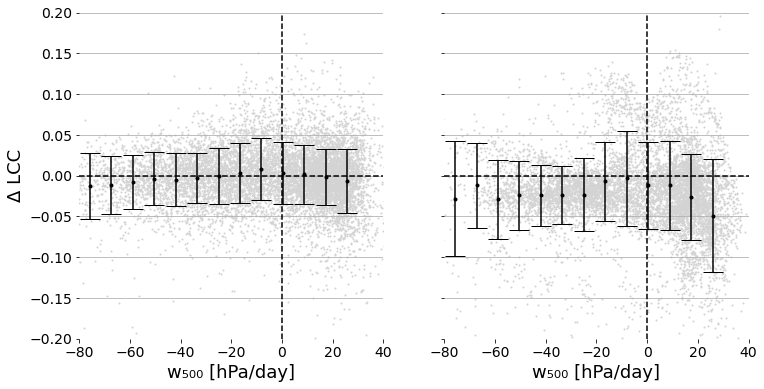

In [81]:
fig, axes = plt.subplots(1, 2, figsize = (12,6), sharey = True)

#axes[0].set_title('2023')
#axes[1].set_title('Compound')


axes[1].errorbar(x = bin_centers, y = means_2023, yerr = stds_2023,
                 fmt = '.', c = 'k', capsize = 10)
axes[1].scatter(w_values23, dlcc_values23, s = 1, c = 'lightgrey')

axes[0].scatter(w_compound[::5], dlcc_compound[::5], s = 1, c = 'lightgrey')
axes[0].errorbar(x = bin_centers, y = means_compound, yerr = stds_compound,
                 fmt = '.', c = 'k', capsize = 10)





for ax in axes:
    ax.set_ylim(-.2,.2)
    ax.set_xlim(-80, 40)
    ax.axhline(0, c = 'k', linestyle = '--')
    ax.axvline(0, c = 'k', linestyle = '--')   
    ax.spines[:].set_visible(False)
    

    ax.set_xlabel('w₅₀₀ [hPa/day]', fontsize = 18, fontweight = 'normal')
    ax.tick_params(axis='both', labelsize=14) 
    ax.grid(axis = 'y')

axes[0].set_ylabel('Δ LCC', fontsize = 18, fontweight = 'normal')

    